# 학습된 모델 저장

- 학습이 완료된 모델을 파일로 저장하여, 이후 추가 학습이나 예측 서비스에 사용할 수 있도록 한다.
- 파이토치(PyTorch)는 **모델의 파라미터만 저장**하는 방법과 **모델의 구조와 파라미터를 모두 저장**하는 두 가지 방식을 제공한다.
- 저장 함수
  - `torch.save(저장할 객체, 저장 경로)`
- 보통 저장 파일의 확장자는 `.pt`나 `.pth`를 사용한다.

## 모델 전체 저장 및 불러오기

- 저장하기
  - `torch.save(model, 저장 경로)`
- 불러오기
  - `load_model = torch.load(저장 경로, weight_only=True)`
- 모델 저장 시 **피클(pickle)**을 사용해 직렬화되므로, 모델을 불러오는 실행 환경에도 저장할 때 사용한 클래스 정의가 필요하다.


## 모델의 파라미터만 저장

-   모델을 구성하는 파라미터만 저장한다.
-   모델의 구조는 저장하지 않기 때문에 불러올 때 **모델을 먼저 생성하고 생성한 모델에 불러온 파라미터를 덮어씌운다.**
-   모델의 파라미터는 **state_dict** 형식으로 저장한다.

### state_dict

-   모델의 파라미터 Tensor들을 레이어 단위별로 나누어 저장한 Ordered Dictionary (OrderedDict)
-   `모델객체.state_dict()` 메소드를 이용해 조회한다.
-   모델의 state_dict을 조회 후 저장한다.
    -   `torch.save(model.state_dict(), "저장경로")`
-   생성된 모델에 읽어온 state_dict를 덮어씌운다.
    -   `new_model.load_state_dict(torch.load("state_dict저장경로"))`


## Checkpoint 저장 및 불러오기

- 학습이 끝나지 않은 모델을 저장하고, 나중에 이어서 학습시키려면 모델의 구조와 파라미터뿐만 아니라 optimizer, loss 함수 등 학습에 필요한 객체들도 함께 저장해야 한다.
- 딕셔너리(Dictionary)에 저장하려는 값들을 key-value 쌍으로 구성하여 `torch.save()`를 이용해 저장한다.

```python
# 저장
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_loss
}, "저장경로")

# 불러오기
model = MyModel()
optimizer = optim.Adam(model.parameters())

# 불러온 checkpoint를 이용해 이전 학습 상태 복원
checkpoint = torch.load("저장경로")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
```

In [1]:
# 간단한 모델 정의
import torch
import torch.nn as nn

class MyModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(3, 4) # 3 X 4 + 4 
        self.lr2 = nn.Linear(4, 2)
        self.relu = nn.ReLU() # activation함수->파라미터가 없는 단순 계산함수. relu(X) = max(X, 0)
        # ReLU는 현재 파라미터가 없어서 forward에 넣어도? 정의해도? 됨.
        
    def forward(self, X):
        X = self.lr1(X)
        X = self.relu(X)
        X = self.lr2(X)
        return X

In [2]:
# 모델 생성성
model = MyModel()
model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [4]:
################################################
#  모델에 Layer들을 조회. 모델.instance변수명
################################################
lr_layer = model.lr1
lr_layer

Linear(in_features=3, out_features=4, bias=True)

In [5]:
################################################
#  Layer의 파라미터(weight/bias) 조회
################################################
lr1_weight = lr_layer.weight
lr1_bias = lr_layer.bias

In [6]:
lr1_weight

Parameter containing:
tensor([[-0.2906, -0.4125, -0.1739],
        [ 0.1368, -0.1296, -0.1234],
        [-0.4562, -0.0725, -0.4548],
        [-0.3536, -0.4350, -0.2876]], requires_grad=True)

In [7]:
lr1_bias

Parameter containing:
tensor([-0.4407,  0.3122, -0.4523,  0.3666], requires_grad=True)

In [8]:
import os
os.makedirs("saved_models", exist_ok=True)

In [9]:
################################################
#  모델을 저장
################################################
torch.save(model, "saved_models/my_model.pt")

In [11]:
################################################
#  저장된 모델 Load
################################################
load_model = torch.load("saved_models/my_model.pt", weights_only=False)
# weight만 저장된거면 True, 그 외에는 False

In [12]:
load_model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [13]:
load_model.lr1.weight

Parameter containing:
tensor([[-0.2906, -0.4125, -0.1739],
        [ 0.1368, -0.1296, -0.1234],
        [-0.4562, -0.0725, -0.4548],
        [-0.3536, -0.4350, -0.2876]], requires_grad=True)

In [14]:
lr1_weight

Parameter containing:
tensor([[-0.2906, -0.4125, -0.1739],
        [ 0.1368, -0.1296, -0.1234],
        [-0.4562, -0.0725, -0.4548],
        [-0.3536, -0.4350, -0.2876]], requires_grad=True)

In [15]:
######################################################
# 모델의 파라미터들(weight들, bias들)만 저장/불러오기
######################################################
state_dict = model.state_dict()
state_dict

OrderedDict([('lr1.weight',
              tensor([[-0.2906, -0.4125, -0.1739],
                      [ 0.1368, -0.1296, -0.1234],
                      [-0.4562, -0.0725, -0.4548],
                      [-0.3536, -0.4350, -0.2876]])),
             ('lr1.bias', tensor([-0.4407,  0.3122, -0.4523,  0.3666])),
             ('lr2.weight',
              tensor([[ 0.2191,  0.4373,  0.4067,  0.1395],
                      [-0.1343,  0.0164,  0.1017,  0.3178]])),
             ('lr2.bias', tensor([-0.4535,  0.0293]))])

In [16]:
state_dict.keys()

odict_keys(['lr1.weight', 'lr1.bias', 'lr2.weight', 'lr2.bias'])

In [17]:
###################
# state_dict 저장
################### 

torch.save(state_dict, "saved_models/my_model_parameter.pt")

In [20]:
#####################
# state_dict load
#####################
sd = torch.load("saved_models/my_model_parameter.pt") # weight_only = True가 기본값이라 생략 가능
sd

OrderedDict([('lr1.weight',
              tensor([[-0.2906, -0.4125, -0.1739],
                      [ 0.1368, -0.1296, -0.1234],
                      [-0.4562, -0.0725, -0.4548],
                      [-0.3536, -0.4350, -0.2876]])),
             ('lr1.bias', tensor([-0.4407,  0.3122, -0.4523,  0.3666])),
             ('lr2.weight',
              tensor([[ 0.2191,  0.4373,  0.4067,  0.1395],
                      [-0.1343,  0.0164,  0.1017,  0.3178]])),
             ('lr2.bias', tensor([-0.4535,  0.0293]))])

In [19]:
# load한 state_dict를 모델 파라미터에 적용(덮어 씌운다.)
new_model = MyModel()
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[ 0.0318, -0.2865, -0.3036],
                      [ 0.5348, -0.1535,  0.0809],
                      [-0.3832, -0.1028, -0.0641],
                      [ 0.4139, -0.4492, -0.1780]])),
             ('lr1.bias', tensor([ 0.1037, -0.4380,  0.1893,  0.2334])),
             ('lr2.weight',
              tensor([[ 0.1818, -0.2029, -0.2567,  0.0870],
                      [-0.1477,  0.4777, -0.4189, -0.0967]])),
             ('lr2.bias', tensor([0.0767, 0.1041]))])

In [21]:
new_model.load_state_dict(sd)

<All keys matched successfully>

In [22]:
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[-0.2906, -0.4125, -0.1739],
                      [ 0.1368, -0.1296, -0.1234],
                      [-0.4562, -0.0725, -0.4548],
                      [-0.3536, -0.4350, -0.2876]])),
             ('lr1.bias', tensor([-0.4407,  0.3122, -0.4523,  0.3666])),
             ('lr2.weight',
              tensor([[ 0.2191,  0.4373,  0.4067,  0.1395],
                      [-0.1343,  0.0164,  0.1017,  0.3178]])),
             ('lr2.bias', tensor([-0.4535,  0.0293]))])

In [23]:
print(model)

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)


In [25]:
# torchinfo 패키지 설치: 파이토치 모델 구조를 조사해주는 패키지.
# !uv pip install torchinfo

Using Python 3.13.7 environment at: C:\Users\Playdata\Documents\SKN21\JYS\.venv
Resolved 1 package in 118ms
Prepared 1 package in 38ms
Installed 1 package in 44ms
 + torchinfo==1.8.0


In [26]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
MyModel                                  --
├─Linear: 1-1                            16
├─Linear: 1-2                            10
├─ReLU: 1-3                              --
Total params: 26
Trainable params: 26
Non-trainable params: 0

In [27]:
# input data 의 shape을 지정하면 각 Layer의 output shape을 출력한다.
summary(model, (100, 3))

# Linear의 output shape이 [100,2]인데 이게 최종적으로 해당 model의 output shape임을 알 수 있음.

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [100, 2]                  --
├─Linear: 1-1                            [100, 4]                  16
├─ReLU: 1-2                              [100, 4]                  --
├─Linear: 1-3                            [100, 2]                  10
Total params: 26
Trainable params: 26
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

# 문제 유형별 MLP 네트워크
- 해결하려는 문제 유형에 따라 출력 Layer의 구조가 바뀐다.
- 딥러닝 구조에서 **Feature를 추출하는 Layer 들을 Backbone** 이라고 하고 **추론하는 Layer들을 Head** 라고 한다. 


> - MLP(Multi Layer Perceptron), DNN(Deep Neural Network), ANN(Artificial Neural Network)
>     -   Fully Connected Layer(nn.Linear)로 구성된 딥러닝 모델
>     -   input feature들 모두에 대응하는 weight들(가중치)을 사용한다.
> 

## Boston Housing Dataset - **Regression(회귀) 문제**

보스턴 주택가격 dataset은 다음과 같은 속성을 바탕으로 해당 타운 주택 가격의 중앙값을 예측하는 문제.

-   CRIM: 범죄율
-   ZN: 25,000 평방피트당 주거지역 비율
-   INDUS: 비소매 상업지구 비율
-   CHAS: 찰스강에 인접해 있는지 여부(인접:1, 아니면:0)
-   NOX: 일산화질소 농도(단위: 0.1ppm)
-   RM: 주택당 방의 수
-   AGE: 1940년 이전에 건설된 주택의 비율
-   DIS: 5개의 보스턴 직업고용센터와의 거리(가중 평균)
-   RAD: 고속도로 접근성
-   TAX: 재산세율
-   PTRATIO: 학생/교사 비율
-   B: 흑인 비율
-   LSTAT: 하위 계층 비율
    <br><br>
-   **Target**
    -   MEDV: 타운의 주택가격 중앙값(단위: 1,000달러)


In [51]:
import pandas as pd

df = pd.read_csv('data/boston_housing.csv')
print(df.shape)

(506, 14)


In [37]:
X = df.drop(columns='MEDV').values
y = df['MEDV'].values.reshape(-1,1)
y.shape

(506, 1)

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
# Train/Test Data set
from torch.utils.data import TensorDataset
trainset = TensorDataset(
    torch.tensor(X_train, dtype = torch.float32),
    torch.tensor(y_train, dtype = torch.float32)
)

testset = TensorDataset(
       torch.tensor(X_test, dtype = torch.float32),
       torch.tensor(y_test, dtype = torch.float32)
)

len(trainset), len(testset)

(404, 102)

In [55]:
# Dataloader 생성
batch_size = 200
from torch.utils.data import DataLoader
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(testset, batch_size= len(testset))

In [ ]:
##############
# 모델 정의
###############
import torch
import torch.nn as nn
class BostonModel(nn.Module) : 

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(13, 32) # 첫번째 연산 layer, (X의 데이터 수, 내가 원하는 데이터 수) 이므로 X_train.shape으로 데이터 개수를 확인 → (404,13)
        self.lr2 = nn.Linear(32, 16)
        self.lr3 = nn.Linear(16, 1) # 추론 결과를 출력. (out DATA , y) 이므로 y_train.shape으로 데이터 개수 확인해서 y값에 맞춰줌 → (404,1) 
        self.relu = nn.ReLU()

    def forward(self, X) : 
        # Linear → ReLU → Linear → ReLU → Linear → 출력
        out = self.lr1(X)
        out = self.relu(out)
        out = self.lr2(out)
        out = self.relu(out)
        out = self.lr3(out)
        return out # 최종 예측 결과 


In [ ]:
epochs = 1000
lr =0.001
device = "cuda" if  torch.cuda.is_available() else "cpu"

train_loss_list = []
valid_loss_list = []

# 모델 생성
boston_model = BostonModel().to(device)

# LOSS 함수
loss_fn = nn.MSELoss()

# Optimizer
optimizer = torch.optim.RMSprop(boston_model.parameters(), lr=lr) # 일반적으론 아담을 씀 

In [74]:
# Train → Train / Validation 두 단계로 나눠짐
for epoch in range(epochs) :

    # 학습 단계(train)
    boston_model.train()
    train_loss = 0.0 # 현재 epoch의 loss를 저장할 변수
    for X_train, y_train in train_loader : # 1 batch 학습
        # 1. X, y → device(model과 같은 device)로 이동
        X_train, y_train = X_train.to(device), y_train.to(device)

        # 2. 추론
        pred_train = boston_model(X_train)

        # 3. loss 계산
        loss = loss_fn(pred_train, y_train) # model이 예측한거 먼저(pred_train), 정답을 그 뒤에(y_train)

        # 학습에서의 순 전파는 여기까지.
        # 이 다음부터는 역전파

        # 4. 역전파로 gradient 계산
        loss.backward()

        # 5. parameter 업데이트
        optimizer.step()

        # 6. gradient 초기화
        optimizer.zero_grad()
        

        # 7. 현재 batch에 대한 loss 계산
        train_loss += loss.item()

        # 여기까지가 1 epoch가 끝남.
        train_loss = train_loss / len(train_loader)
    train_loss_list.append(train_loss)
    

    # 검증 단계 (validation) - 1 epoch 학습에 대한 검증. 학습이 다 끝나고 검증하는 것 x 
    boston_model.eval() # 추론만 할 때 사용.

    valid_loss = 0.0 # 현재 epoch에 대한 검증 loss값을 저장할 변수 
    with torch.no_grad() : # gradient 함수 만들지 말라는 뜻
        for X_valid, y_valid in test_loader :
            # 1. X와 y를 model의 device로 이동
            X_valid, y_valid = X_valid.to(device), y_valid.to(device)

            # 2. 추론
            pred_valid = boston_model(X_valid)

            # 3. 평가 - MSE로 
            valid_loss += loss_fn(pred_valid, y_valid).item()
        valid_loss = valid_loss / len(test_loader)
        valid_loss_list.append(valid_loss)
    # 로그 출력 - train/valid loss를 출력
    if epoch % 100 == 0 or epoch == epochs-1 : #(epochs-1)은 마지막 epoch를 의미함
        print(f'[{epoch+1}/{epochs}] train loss: {train_loss:.5f}, validation loss: {valid_loss:.5f}')

# 실행하는 만큼 loss 수가 줄어드는 것을 확인할 수 있음 (이어서 학습한다는 뜻.)
# 만일 새로 계산하고싶으면 위 cell인 모델 생성부터 다시 실행해야 함.

[1/1000] train loss: 446.88516, validation loss: 514.97034
[101/1000] train loss: 19.00306, validation loss: 27.44540
[201/1000] train loss: 11.25920, validation loss: 18.06610
[301/1000] train loss: 8.50436, validation loss: 14.57187
[401/1000] train loss: 6.10534, validation loss: 12.85901
[501/1000] train loss: 5.59129, validation loss: 12.11558
[601/1000] train loss: 4.84028, validation loss: 11.94135
[701/1000] train loss: 4.21635, validation loss: 11.97478
[801/1000] train loss: 3.75994, validation loss: 11.82714
[901/1000] train loss: 3.53932, validation loss: 11.77328
[1000/1000] train loss: 3.22567, validation loss: 11.75516


In [ ]:
# model 전체 저장
saved_boston_model_path = "saved_models/boston_model.pth"
torch.save(boston_model, saved_boston_model_path)

# parameter만 저장
torch.save(boston_model.state_dict(), "saved_models/boston_model_parameter.pth")

In [83]:
load_model = torch.load(saved_boston_model_path, weights_only= False) # 모델을 읽어볼 때는 False,
load_model.eval()
with torch.no_grad():
    print(load_model(X_valid[:10]))

tensor([[27.4304],
        [33.3180],
        [16.5055],
        [24.0324],
        [16.5379],
        [19.9956],
        [18.9371],
        [17.1595],
        [25.3288],
        [20.1590]])


In [84]:
load_state_dict = torch.load("saved_models/boston_model_parameter.pth", weights_only=True) # parameter를 잃을 땐 True
new_model = BostonModel()
new_model.load_state_dict(load_state_dict)
new_model.eval() # model을 추론할 때 mode 변경을 위해 사용
with torch.no_grad(): # 얘도 같이 사용
    result = new_model(X_valid[:10])
    print(result)

tensor([[27.4304],
        [33.3180],
        [16.5055],
        [24.0324],
        [16.5379],
        [19.9956],
        [18.9371],
        [17.1595],
        [25.3288],
        [20.1590]])


## 분류 (Classification)

### Fashion MNIST Dataset - **다중분류(Multi-Class Classification) 문제**

10개의 범주(category)와 70,000개의 흑백 이미지로 구성된 [패션 MNIST](https://github.com/zalandoresearch/fashion-mnist) 데이터셋.
이미지는 해상도(28x28 픽셀)가 낮고 다음처럼 개별 의류 품목을 나타낸다:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>그림</b> <a href="https://github.com/zalandoresearch/fashion-mnist">패션-MNIST 샘플</a> (Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

- **Feature**이미지는 28x28 크기이며 Gray scale이다.
- **Target**은 총 10개의 class로 구성되어 있으며 각 class의 class 이름은 다음과 같다.

| 레이블 | 클래스       |
|--------|--------------|
| 0      | T-shirt/top |
| 1      | Trousers    |
| 2      | Pullover    |
| 3      | Dress       |
| 4      | Coat        |
| 5      | Sandal      |
| 6      | Shirt       |
| 7      | Sneaker     |
| 8      | Bag         |
| 9      | Ankle boot  |

> #### 학습 도중 모델 저장
>
> - 학습 도중 가장 좋은 성능을 보이는 모델이 나올 수 있다.
> - 학습 도중 모델을 저장하는 방법
>   1. 각 에폭이 끝날 때 마다 모델을 저장한다.
>   2. 한 에폭 학습 후 성능 개선이 있으면 모델을 저장하여 가장 성능 좋은 모델만 저장되도록 한다.
>      - 최고 성능 점수(best score)와 현재 에폭의 성능을 비교하여, 성능이 개선되었을 경우 모델을 저장(덮어쓰기)한다.
>
> #### 조기 종료(Early Stopping)
>
> - 학습 도중 성능 개선이 나타나지 않으면, 중간에 학습을 종료하도록 구현한다.
> - 에폭 수를 충분히 길게 설정한 뒤, 특정 횟수 동안 성능 개선이 없으면 학습을 조기 종료하도록 구현한다.


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import FashionMNIST
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"



In [3]:
# Dataset
batch_size = 256
dataset_path = "datasets/fation_mnist"
f_trainset = FashionMNIST(dataset_path, train=True, download=True, transform=transforms.ToTensor() )
f_testset = FashionMNIST(dataset_path, train=False, download=True, transform=transforms.ToTensor() )
f_trainset, f_validset = random_split(f_trainset, [50000,10000])
# 원래 60,000개던 trainset을 50000,10000로 나눔

f_train_loader = DataLoader(f_trainset, batch_size=batch_size, shuffle=True, drop_last=True)
f_valid_loader = DataLoader(f_validset, batch_size=batch_size)
f_test_loader = DataLoader(f_testset, batch_size=batch_size)

len(f_trainset), len(f_testset), len(f_validset), len(f_train_loader), len(f_test_loader)

(50000, 10000, 10000, 195, 40)

In [4]:
f_testset.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [5]:
f_testset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
# f_trainset.classes

In [7]:
print(f_trainset[0][0].dtype)
print(f_trainset[0][0].size())
print(f_trainset[0][0].min(), f_trainset[0][0].max())

torch.float32
torch.Size([1, 28, 28])
tensor(0.) tensor(1.)


In [8]:
# model 정의
class FashionMNISTModel(nn.Module):

    def __init__(self):
        super().__init__() 
        self.lr1 = nn.Linear(28*28, 2048) # 계산된 값인 784를 넣어도 됨.
        self.lr2 = nn.Linear(2048, 1024)
        self.lr3 = nn.Linear(1024, 512)
        self.lr4 = nn.Linear(512, 256)
        self.lr5 = nn.Linear(256, 128)
        self.lr6 = nn.Linear(128, 64)
        self.lr7 = nn.Linear(64, 10)

        # 출력 Layer out_features 개수 : 다중분류문제의 경우 정답 클래스 개수 
        self.relu = nn.ReLU()


    def forward(self, X):
        # X.shape : (batch, 1, 28, 28) → (batch, 784)로 바꿀건데, 이 방식엔 
        # flatten (start_dim = 1) 함수, 다차원을 1차원 배열로 반환하는 해당 방식도 있지만
        out = nn.Flatten()(X) # 0 번축은 내두고 0번축 이후의 축을 flatten 형식으로 바꿔주는 이 방식도 존재함.
        # out = self.relu(self.lr1(X)) # 이 방식도 가능하지만 가독성면에선 떨어짐(비추)
        out = self.lr1(out)
        out = self.relu(out)

        out = self.lr2(out)
        out = self.relu(out)

        out = self.lr3(out)
        out = self.relu(out)

        out = self.lr4(out)
        out = self.relu(out)

        out = self.lr5(out)
        out = self.relu(out)

        out = self.lr6(out)
        out = self.relu(out)
        
        out = self.lr7(out)
        return out
    

In [9]:
from torchinfo import summary
summary(FashionMNISTModel(), (100,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTModel                        [100, 10]                 --
├─Linear: 1-1                            [100, 2048]               1,607,680
├─ReLU: 1-2                              [100, 2048]               --
├─Linear: 1-3                            [100, 1024]               2,098,176
├─ReLU: 1-4                              [100, 1024]               --
├─Linear: 1-5                            [100, 512]                524,800
├─ReLU: 1-6                              [100, 512]                --
├─Linear: 1-7                            [100, 256]                131,328
├─ReLU: 1-8                              [100, 256]                --
├─Linear: 1-9                            [100, 128]                32,896
├─ReLU: 1-10                             [100, 128]                --
├─Linear: 1-11                           [100, 64]                 8,256
├─ReLU: 1-12                             [100, 64]    

In [10]:
# 학습
f_model = FashionMNISTModel().to(device)
optimizer = torch.optim.Adam(f_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss() # 다중 분류의 loss : Cross Entropy Loss
# CRL() → 정답 : class index로 구성 [[3],[8],[0]..]  / 모델 추정 결과 : softmax를 적용하기 전 값(logit 값)

In [11]:
import time
train_loss_list = []
valid_loss_list = []
valid_acc_list = []

# 1. 성능이 개선될 때마다 모델을 저장. → 최종적으로 가장 성능이 좋은 epoch의 모델이 저장되도록 함.
# 2. 일정 epoch 동안 성능 개선이 안되면 학습을 중단. 
# 이것과 관련된 변수들을 정의.

best_score = torch.inf # 가장 좋은 valid_loss 값을 저장 
    # loss는 오차의 값을 나타내는 것으로, 가장 낮은 값이 좋음. 때문에 0보다 낮을수없을 값으로 정의(inf : infiniti 값)

# 저장
save_model_path = "saved_models/fasion_mnist_model.pth"


# 조기종료
patience = 10 # 성능이 개선되었는지 10 epoch 동안 기다려 본다.
stop_count = 0 # 학습하는 도중 몇번동안 성능 개선이 안되었는지 저장할 변수. stop_count == patience 이면 종료 

epochs = 100 # 학습할 수 
s = time.time()

for epoch in range(epochs) : 
    # 학습
    f_model.train()

    train_loss = 0.0
    for X_train, y_train in f_train_loader:

        # 1. X와 y를 device로 이동
        X_train, y_train = X_train.to(device), y_train.to(device)

        # 2. 모델 추론
        pred_train = f_model(X_train)

        # 3. loss 계산
        loss = loss_fn(pred_train, y_train)

        # 4. gradient 계산
        loss.backward()

        # 5. 파라미터 업데이트
        optimizer.step()

        # 6. 파라미터 초기화
        optimizer.zero_grad()

        # 7. 현재 epoch에서의 train loss 누적
        train_loss = train_loss + loss.item()
     
        # 8. train loss 평균 계산
        train_loss = train_loss / len(f_train_loader)
    train_loss_list.append(train_loss)

    # 검증
    f_model.eval()

    valid_loss = 0.0 # 현재 epoch에 대한 검증 loss값을 저장할 변수 
    valid_acc = 0.0
    with torch.no_grad() : # gradient 함수 만들지 말라는 뜻
        for X_valid, y_valid in f_valid_loader :
            # 1. X와 y를 model의 device로 이동
            X_valid, y_valid = X_valid.to(device), y_valid.to(device)

            # 2. 추론
            pred_valid = f_model(X_valid) # 10개 class에 대한 logit 값.
            pred_label = pred_valid.argmax(dim=-1) # 가장 확률 높은 class를 뽑아냄
            # argmax는 가장 큰값을 가진 index를 뽑아냄

            # 3. 평가 - loss와 정확도
            valid_loss += loss_fn(pred_valid, y_valid).item()
            valid_acc += torch.sum(pred_label == y_valid).item() # 현 step에서 맞은 것 개수.
            # torch.sum(pred_label == y_valid) # True의 개수가 나옴

        valid_loss = valid_loss / len(f_valid_loader)
        valid_acc = valid_acc / len(f_validset)
        
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)

        # 로그 출력 - train/valid loss, valid acc를 출력
        print(f'[{epoch+1}/{epochs}] train loss: {train_loss:.5f}, valid loss: {valid_loss:.5f}, valid acc: {valid_acc:.5f}')

        # 모델 저장 & 조기종료
        if valid_loss < best_score : # 이번 epoch 학습에서 성능(valid_loss)이 개선되었는지
            torch.save(f_model, save_model_path) # 모델 저장 
            print(f">>>>>> 모델 저장 : {epoch+1} epoch - 이전 score : {best_score}, 개선된 score : {valid_loss}")
            best_score = valid_loss
            # 조기종료(stop_count를 초기화) 
            stop_count = 0
        else : # 성능개선이 안됨
            stop_count += 1
            if stop_count == patience :
                print(f">>>>>>>>>> 조기 종료 : {best_score} 보다 개선되지 않음.")
                break


e = time.time()
print('학습에 걸린 시간:', (e-s), "초")

[1/100] train loss: 0.00236, valid loss: 0.48451, valid acc: 0.82640
>>>>>> 모델 저장 : 1 epoch - 이전 score : inf, 개선된 score : 0.4845107667148113
[2/100] train loss: 0.00195, valid loss: 0.42958, valid acc: 0.84690
>>>>>> 모델 저장 : 2 epoch - 이전 score : 0.4845107667148113, 개선된 score : 0.4295848682522774
[3/100] train loss: 0.00195, valid loss: 0.38073, valid acc: 0.86080
>>>>>> 모델 저장 : 3 epoch - 이전 score : 0.4295848682522774, 개선된 score : 0.3807274255901575
[4/100] train loss: 0.00146, valid loss: 0.36122, valid acc: 0.87160
>>>>>> 모델 저장 : 4 epoch - 이전 score : 0.3807274255901575, 개선된 score : 0.36121657863259315
[5/100] train loss: 0.00153, valid loss: 0.33419, valid acc: 0.87700
>>>>>> 모델 저장 : 5 epoch - 이전 score : 0.36121657863259315, 개선된 score : 0.3341878727078438
[6/100] train loss: 0.00140, valid loss: 0.33808, valid acc: 0.87840
[7/100] train loss: 0.00149, valid loss: 0.33100, valid acc: 0.88530
>>>>>> 모델 저장 : 7 epoch - 이전 score : 0.3341878727078438, 개선된 score : 0.33099504858255385
[8/100]

In [45]:
import pickle
result_dict = {
    "train_loss" : train_loss_list,
    "valid_loss" : valid_loss_list,
    "valid_acc" : valid_acc_list
}

with open("f_mnist_train_result.pkl", 'wb') as fo: # 'wb' : 쓰기모드
    pickle.dump(result_dict, fo)

In [46]:
import pickle
with open("f_mnist_train_result.pkl", 'rb') as fi:
    load_result = pickle.load(fi)

load_result

{'train_loss': [0.002363704590643904,
  0.001946657433872781,
  0.0019527205652343398,
  0.0014552044111217867,
  0.0015252165260258488,
  0.0013981301999498343,
  0.0014859170575223064,
  0.0016432546903463513,
  0.0015802930709873436,
  0.001438383140302946,
  0.0010968764199064908,
  0.0010418750386038964,
  0.00103672930573022,
  0.0011284699610101063,
  0.0011398799326457184,
  0.000987621801164345,
  0.001266342876974666,
  0.0009070113966337535,
  0.0009416279862969495,
  0.0012236681232574386,
  0.0009410588960715572,
  0.0008305752688627041,
  0.0011270565811817039,
  0.0007768086481807046],
 'valid_loss': [0.4845107667148113,
  0.4295848682522774,
  0.3807274255901575,
  0.36121657863259315,
  0.3341878727078438,
  0.33808031529188154,
  0.33099504858255385,
  0.32729987017810347,
  0.3192389067262411,
  0.32810674495995046,
  0.35914652831852434,
  0.3472863301634789,
  0.31898689158260823,
  0.30799358151853085,
  0.3295340593904257,
  0.34698800928890705,
  0.3177898295223

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

result_df = pd.DataFrame(load_result)
result_df

,train_loss,valid_loss,valid_acc
0,0.002364,0.484511,0.8264
1,0.001947,0.429585,0.8469
2,0.001953,0.380727,0.8608
3,0.001455,0.361217,0.8716
4,0.001525,0.334188,0.8770
5,0.001398,0.338080,0.8784
6,0.001486,0.330995,0.8853
7,0.001643,0.327300,0.8836
8,0.001580,0.319239,0.8868
9,0.001438,0.328107,0.8861


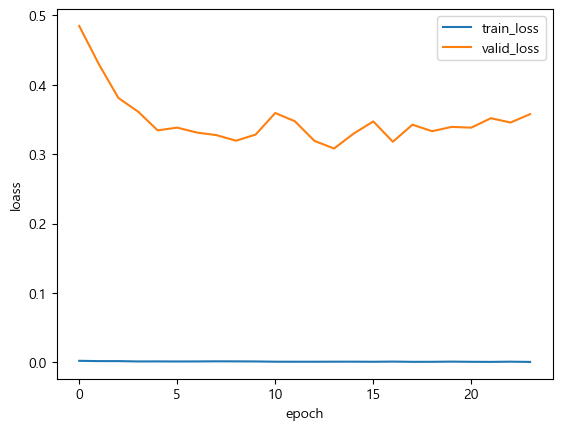

In [23]:
result_df[["train_loss","valid_loss"]].plot(xlabel="epoch",ylabel="loass");

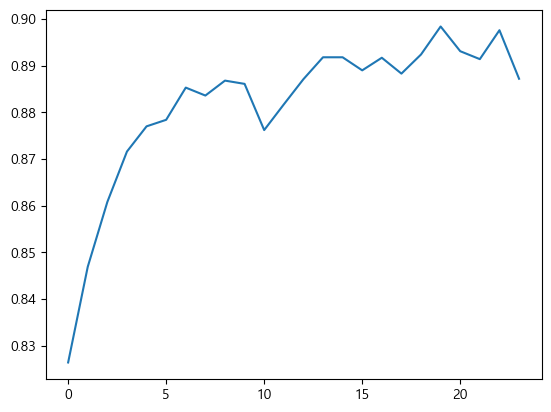

In [24]:
result_df['valid_acc'].plot();

In [25]:
result_df['valid_acc'].max()

np.float64(0.8984)

In [50]:
# 저장된 모델 load
save_model_path = "saved_models/fasion_mnist_model.pth"
load_model = torch.load(save_model_path, weights_only=False)
load_model

FashionMNISTModel(
  (lr1): Linear(in_features=784, out_features=2048, bias=True)
  (lr2): Linear(in_features=2048, out_features=1024, bias=True)
  (lr3): Linear(in_features=1024, out_features=512, bias=True)
  (lr4): Linear(in_features=512, out_features=256, bias=True)
  (lr5): Linear(in_features=256, out_features=128, bias=True)
  (lr6): Linear(in_features=128, out_features=64, bias=True)
  (lr7): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

In [52]:
# Testset으로 최종 평가
load_model = load_model.to(device)
load_model.eval()
loss = 0.0
acc = 0.0
loss_fn = nn.CrossEntropyLoss()
with torch.no_grad():
    for X, y in f_test_loader : 
        X, y = X.to(device), y.to(device) # device로 옮기기
        pred = load_model(X) # 모델 추론
        pred_label = pred.argmax(dim=-1)
        # 평가
        loss += loss_fn(pred,y).item()
        acc += torch.sum(y == pred_label).item()
    loss /= len(f_test_loader)
    acc /= len(f_testset)

print("loss", loss)
print("acc", acc)

loss 0.33391786124557254
acc 0.8845


In [53]:
p = nn.Softmax(dim=-1)(pred)


In [54]:
pred[:2]

tensor([[  1.7720,  -0.2738,  -0.9999,   6.4730,   0.4146,  -7.0851,   2.2864,
          -5.3095,  -1.9533,  -7.2922],
        [  2.9041,  -4.2495,   5.7416,  -1.8514,  -0.6817, -13.3891,   2.0769,
         -15.1177,  -4.0665, -15.6759]])

In [55]:
p[:2]

tensor([[8.8341e-03, 1.1420e-03, 5.5253e-04, 9.7220e-01, 2.2733e-03, 1.2576e-06,
         1.4776e-02, 7.4252e-06, 2.1294e-04, 1.0224e-06],
        [5.3917e-02, 4.2162e-05, 9.2046e-01, 4.6388e-04, 1.4942e-03, 4.5253e-09,
         2.3576e-02, 8.0343e-10, 5.0632e-05, 4.5975e-10]])

### 위스콘신 유방암 데이터셋 - **이진분류(Binary Classification) 문제**

-   **이진 분류 문제 처리 모델의 두가지 방법**
    1. positive(1)일 확률을 출력하도록 구현
        - output layer: units=1, activation='sigmoid'
        - loss: binary_crossentropy
    2. negative(0)일 확률과 positive(1)일 확률을 출력하도록 구현 => 다중분류 처리 방식으로 해결
        - output layer: units=2, activation='softmax', y(정답)은 one hot encoding 처리
        - loss: categorical_crossentropy
-   위스콘신 대학교에서 제공한 종양의 악성/양성여부 분류를 위한 데이터셋
-   Feature
    -   종양에 대한 다양한 측정값들
-   Target의 class
    -   0 - malignant(악성종양)
    -   1 - benign(양성종양)


In [79]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [80]:
# Dataset
X, y = load_breast_cancer(return_X_y=True)
y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=0)

In [81]:
# 전처리
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
# Dataset
## 모델의 weight, bias -> float32. X, y는 weight, bias와 계산을 하게 되기 때문에 타입을 맞춰준다.
trainset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),  
    torch.tensor(y_train, dtype=torch.float32)
)
testset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32), 
    torch.tensor(y_test, dtype=torch.float32)
)

In [60]:
# class name <-> class index
classes = np.array(["악성종양", "양성종양"])
class_to_idx = {"악성종양":0, "양성종양":1}

trainset.classes = classes
trainset.class_to_idx = class_to_idx

In [61]:
trainset.classes[[0,1,1,0,1,1,0,1,1]]

array(['악성종양', '양성종양', '양성종양', '악성종양', '양성종양', '양성종양', '악성종양', '양성종양',
       '양성종양'], dtype='<U4')

In [62]:
# DataLoader
train_loader = DataLoader(trainset, batch_size=200, shuffle=True, drop_last=True)
test_loader = DataLoader(testset, batch_size=100)

In [63]:
X_train.shape
# (426은 데이터 개수, 30은 Feature 개수)

(426, 30)

In [ ]:
######### 모델 정의
class BCModel(nn.Module) : # BCModel이 nn.Module을 상속받음

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(30,16)
        self.lr2 = nn.Linear(16,8)
        self.lr3 = nn.Linear(8,1)
        self.relu = nn.ReLU() # Hidden layer의 활성함수
        self.sigmoid = nn.Sigmoid() # logistic : Linear의 출력값을 0-1 확률로 만들어주는 함수.

    def forward(self, X):
        out = self.relu(self.lr1(X))
        out = self.relu(self.lr2(out))
        out = self.lr3(out)
        out = self.sigmoid(out) # out = self.sigmoid(self.lr3(out))으로도 가능.
        return out

In [75]:
from torchinfo import summary
m = BCModel()
summary(m)
# p = m(torch.rand(10, 30))
# p

Layer (type:depth-idx)                   Param #
BCModel                                  --
├─Linear: 1-1                            496
├─Linear: 1-2                            136
├─Linear: 1-3                            9
├─ReLU: 1-4                              --
├─Sigmoid: 1-5                           --
Total params: 641
Trainable params: 641
Non-trainable params: 0

In [76]:
######### 학습
train_loss_list = []
valid_loss_list = []
valid_acc_list = []

epochs = 1000

model = BCModel().to(device)
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 조기종료, best_score 저장
best_score = torch.inf # valid loss 기준
save_model_path = "saved_models/bc_model.pth"
patience = 10
stop_count = 0

In [89]:
for epoch in range(epochs) :
    # 학습
    model.train()
    train_loss = 0.0
    for X_train, y_train in train_loader:
        # 1. device로 이동
        X_train, y_train = X_train.to(device), y_train.to(device)
        
        # 2. 추론
        pred_train = model(X_train)
        
        #3. loss
        loss = loss_fn(pred_train, y_train)

        # 4. gradient 계산
        loss.backward()

        # 5. parametere update
        optimizer.step()

        # 6.parameter 초기화
        optimizer.zero_grad()

        # 7. loss 누적
        train_loss += loss.item()

    # train loss average
    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)


    #검증
    model.eval()
    valid_loss = 0
    valid_acc = 0
    with torch.no_grad() :
        for X_valid, y_valid in test_loader :
            # 1. device 이동
            X_valid, y_valid = X_valid.to(device), y_valid.to(device)

            # 2. 추론
            pred_valid = model(X_valid) # (batch,1) →  1축 : positive일 확률
            pred_label = (pred_valid > 0.5).type(torch.int32) # label 출력

            # 3. 평가
            valid_loss += loss_fn(pred_valid, y_valid).item()
            valid_acc += torch.sum(pred_label == y_valid).item() # 맞은 개수 
        
        valid_loss /= len(test_loader)
        valid_acc /= len(testset)
        
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)


        print(f"[{epoch+1}/{epochs}] train_loss : {train_loss:.5f}, valid_loss : {valid_loss:.5f}, valid_acc : {valid_acc}")

        # 성능 개선시 모델 저장 및 조기 종료
        if valid_loss < best_score: # 작을수록 효율이 좋은거니까(개선된거니까)
            # 모델 저장 + stop_count 초기화
            print(f">>>>> {epoch+1} Epoch에서 모델을 저장합니다. {best_score}에서 {valid_loss}로 개선됨 ")
            torch.save(model, save_model_path)
            best_score = valid_loss
            stop_count = 0

            # 조기종료
        else :
            stop_count += 1
            if stop_count == patience :
                print(f">>>>> {epoch+1} Epoch에서 모델을 조기 종료합니다. {best_score}에서 개선이 안됨.")
                break



[1/1000] train_loss : 0.58700, valid_loss : 0.55353, valid_acc : 0.6293706293706294
>>>>> 1 Epoch에서 모델을 저장합니다. inf에서 0.5535283088684082로 개선됨 
[2/1000] train_loss : 0.53900, valid_loss : 0.49708, valid_acc : 0.6573426573426573
>>>>> 2 Epoch에서 모델을 저장합니다. 0.5535283088684082에서 0.49708448350429535로 개선됨 
[3/1000] train_loss : 0.48149, valid_loss : 0.43387, valid_acc : 0.7692307692307693
>>>>> 3 Epoch에서 모델을 저장합니다. 0.49708448350429535에서 0.433868944644928로 개선됨 
[4/1000] train_loss : 0.40568, valid_loss : 0.37447, valid_acc : 0.8671328671328671
>>>>> 4 Epoch에서 모델을 저장합니다. 0.433868944644928에서 0.3744734078645706로 개선됨 
[5/1000] train_loss : 0.34618, valid_loss : 0.32339, valid_acc : 0.9230769230769231
>>>>> 5 Epoch에서 모델을 저장합니다. 0.3744734078645706에서 0.32339097559452057로 개선됨 
[6/1000] train_loss : 0.28546, valid_loss : 0.27823, valid_acc : 0.9230769230769231
>>>>> 6 Epoch에서 모델을 저장합니다. 0.32339097559452057에서 0.2782279849052429로 개선됨 
[7/1000] train_loss : 0.22788, valid_loss : 0.23744, valid_acc : 0.9300

In [90]:
p = m(torch.rand(10,30))
(p > 0.5).type(torch.int32)

# bool type을 int로 변환하면 True → 1, False → 0으로 바뀜

tensor([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=torch.int32)

In [91]:
######### 저장된 모델 로드
load_bc_model = torch.load(save_model_path, weights_only=False)
load_bc_model

BCModel(
  (lr1): Linear(in_features=30, out_features=16, bias=True)
  (lr2): Linear(in_features=16, out_features=8, bias=True)
  (lr3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [92]:
###### 추론 함수 #######
def predict_bc(model, X, device="cpu"):
    # model로 X를 추론한 결과를 반환
    # label, 확률
    result = []
    with torch.no_grad():
        pred_proba = model(X)
        pred_class = (pred_proba > 0.5).type(torch.int32)
        for class_index, proba in zip(pred_class, pred_proba):
            # print(class_index, proba if class_index.item() == 1 else 1-proba)
            result.append((class_index.item(), proba if class_index.item() == 1 else 1-proba))
        return result

In [ ]:
# @ torch.no_grad() 이런식으로 위에 올려서 해도 됨 
# def predict_bc(model, X, device="cpu"):
#     # model로 X를 추론한 결과를 반환
#     # label, 확률
#     result = []
#     pred_proba = model(X)
#     pred_class = (pred_proba > 0.5).type(torch.int32)
#     for class_index, proba in zip(pred_class, pred_proba):
#      # print(class_index, proba if class_index.item() == 1 else 1-proba)
#     result.append((class_index.item(), proba if class_index.item() == 1 else 1-proba))
#     return result

In [93]:
new_data = torch.tensor(X_test_scaled[:5], dtype=torch.float32)


In [95]:
result = predict_bc(load_bc_model, new_data)
result

[(1, tensor([0.9992])),
 (0, tensor([0.9971])),
 (0, tensor([0.9932])),
 (1, tensor([1.0000])),
 (0, tensor([0.9360]))]

In [88]:
y_test[:5]

array([[1],
       [0],
       [0],
       [1],
       [0]])

In [96]:
model = BCModel()
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [101]:
from module.train import fit

result = fit(
    train_loader, test_loader,
    model, loss_fn, optimizer,
    epochs=1000, save_best_model=True,
    save_model_path="saved_models/bc_model2.pth",
    device = device, mode = "binary"
    )

Epoch[1/1000] - Train loss: 0.03707 Train Accucracy: 0.92958 || Validation Loss: 0.11431 Validation Accuracy: 0.95804
저장: 1 - 이전 : inf, 현재: 0.11430677399039268
Epoch[2/1000] - Train loss: 0.03660 Train Accucracy: 0.92958 || Validation Loss: 0.11444 Validation Accuracy: 0.95804
Epoch[3/1000] - Train loss: 0.03624 Train Accucracy: 0.92958 || Validation Loss: 0.11451 Validation Accuracy: 0.95804
Epoch[4/1000] - Train loss: 0.03601 Train Accucracy: 0.92958 || Validation Loss: 0.11461 Validation Accuracy: 0.95804
Epoch[5/1000] - Train loss: 0.03453 Train Accucracy: 0.92958 || Validation Loss: 0.11474 Validation Accuracy: 0.95804
Epoch[6/1000] - Train loss: 0.03364 Train Accucracy: 0.92958 || Validation Loss: 0.11490 Validation Accuracy: 0.95804
Epoch[7/1000] - Train loss: 0.03039 Train Accucracy: 0.93192 || Validation Loss: 0.11502 Validation Accuracy: 0.95804
Epoch[8/1000] - Train loss: 0.03502 Train Accucracy: 0.93192 || Validation Loss: 0.11516 Validation Accuracy: 0.95105
Epoch[9/1000] 

# 모델 유형별 구현 정리

## 공통

-   Input layer(첫번째 Layer)의 in_features
    -   입력데이터의 feature(속성) 개수에 맞춰준다.
-   Hidden layer 수
    -   경험적(art)으로 정한다.
    -   Hidden layer에 Linear를 사용하는 경우 보통 feature 수를 줄여 나간다. (핵심 특성들을 추출해나가는 과정의 개념.)

## 회귀 모델

-   output layer의 출력 unit개수(out_features)
    -   정답의 개수
    -   ex
        -   집값: 1
        -   아파트가격, 단독가격, 빌라가격: 3 => y의 개수에 맞춘다.
-   출력 Layer에 적용하는 activation 함수
    -   일반적으로 **None**
    -   값의 범위가 설정되 있고 그 범위의 값을 출력하는 함수가 있을 경우
        -   ex) 0 ~ 1: logistic(Sigmoid), -1 ~ 1: hyperbolic tangent(Tanh)
-   loss함수
    -   MSELoss
-   평가지표
    -   MSE, RMSE, R square($R^2$)

## 다중분류 모델

-   output layer의 unit 개수
    -   정답 class(고유값)의 개수
-   출력 Layer에 적용하는 activation 함수
    -   Softmax: 클래스별 확률을 출력
-   loss함수
    -   **categrocial crossentropy**
    -   파이토치 함수
        -   **CrossEntropyLoss** = NLLLoss(정답) + LogSoftmax(모델 예측값)
        -   **NLLLoss**
            -   정답을 OneHot Encoding 처리 후 Loss를 계산한다.
            -   입력으로 LogSoftmax 처리한 모델 예측값과 onehot encoding 안 된 정답을 받는다.
        -   **LogSoftmax**
            -   입력값에 Softmax 계산후 그 Log를 계산한다.
                -   NLLLoss의 모델 예측값 입력값으로 처리할 때 사용한다.

```python
pred = model(input)
loss1 = nn.NLLLoss(nn.LogSoftmax(dim=-1)(pred), y)
# or
loss2 = nn.CrossEntropyLoss()(pred, y)
```

## 이진분류 모델

-   output layer의 unit 개수
    -   1개 (positive일 확률)
-   출력 Layer에 적용하는 activation 함수
    -   Sigmoid(Logistic)
-   loss 함수
    -   **Binary crossentropy**
    -   파이토치 함수: **BCELoss**
